# Compression Apporaches for Quaternions

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from copy import deepcopy
import numpy as np
import pandas as pd
from scipy.fft import dctn, idctn
from scipy.linalg import eigh

from src.data import load_clip, save_clip, extract_tracks, get_joint_idx
from src.cagd.lspia.solver import LSPIASolver
from src.cagd.lspia.initializer import SimpleInitializer
from src.cagd.lspia.knot_topo import BoehmKnotOptimizer
from src.processing import AntipodalPreprocessor, TrackBaker

import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Tahiti', 'Thonburi', 'Leelawadee', 'Garuda', 'Sarabun']

In [4]:
CLIP_IDX = 481
# CLIP_IDX = 175

### Summary

- **Antipodality is a big problem**, alignment is required to prevent problem in spline fitting and interpolation. 
    - It does not effect visual fidelity when running on ThreeJS, but very high impact on spline fitting performance.
- Moderate times uniqueness problem.
    - Time sharing can be apply if needed.
    - *Should not matter if baking will be utilize*.
- Baking is needed if spline fitting require joints to be dependent since joint times are mostly inconsistance.
- **PCA (Eigen-Poses) are quite reliable**, they can provide impressive compression on the hands.
    - Doing so on other chains like arms will cause CATASTROPHIC FAILURE, causing far too much loss.
- Both sub-sampling & DCT are tangible for residuals compression.
    - DCT seem to provide more compression ratio, but require more complicated encoder/decoder.

---
## Load Test Clip

In [5]:
original_clip = load_clip(f"data/json/clip_{CLIP_IDX}.json")

original_tracks = original_clip["animationClip"]["tracks"]
number_tracks = extract_tracks(original_tracks, type="number")
quater_tracks = extract_tracks(original_tracks, type="quaternion")

original_test_joint_track = quater_tracks[get_joint_idx(quater_tracks, "handr")]

In [6]:
temp = deepcopy(original_clip)
temp["animationClip"]["tracks"] = "tracks"
temp

{'_id': {'$oid': '67cc083cfd081b0548566508'},
 'animationClip': {'name': '-1741424699845',
  'duration': 7.153490000000602,
  'tracks': 'tracks',
  'uuid': '86c11ac9-14a8-4174-a71b-092ee59ed729',
  'blendMode': 2500},
 'recordDate': 1741424699846}

#### Plot Util

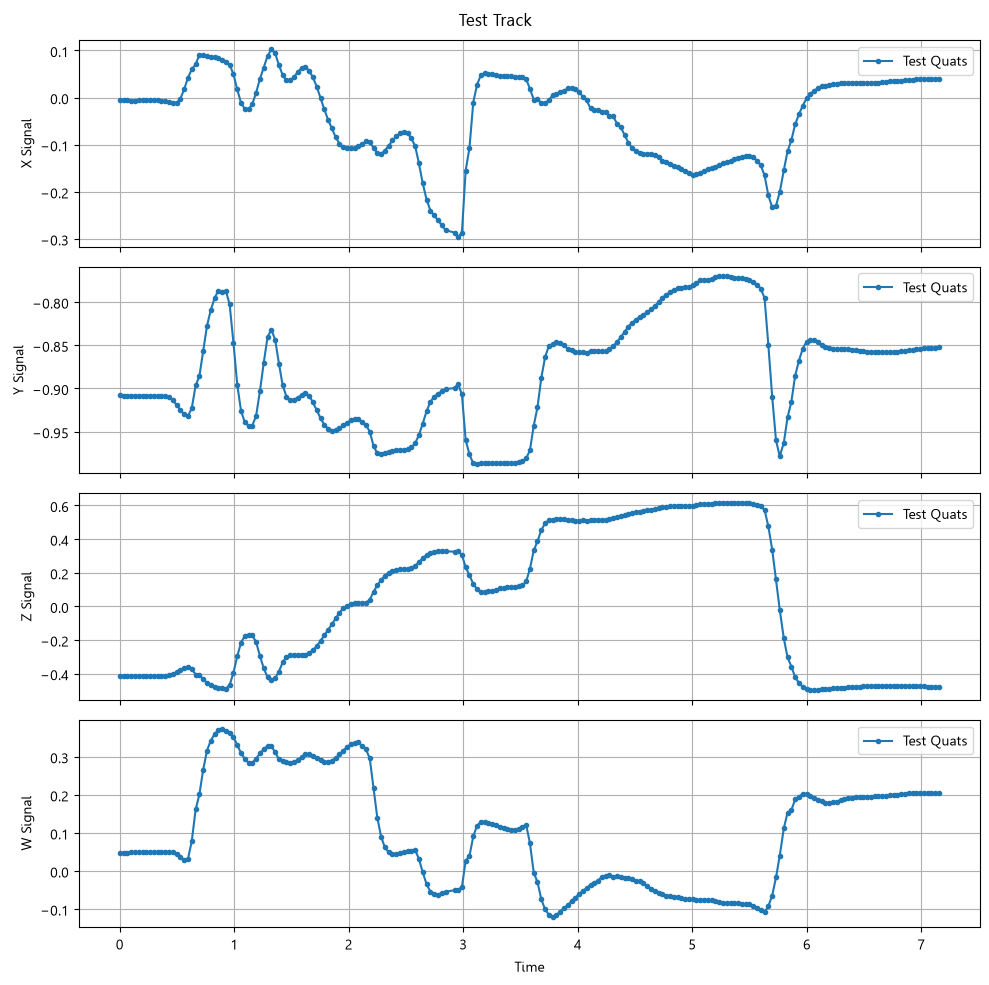

In [7]:
def plot_quat_signals(quats_dict, stride=1):
    """
    quats_dict = dict(
        data: dict(, times: 1darray, values: 4darray, label: str, fmt: str[marker|line|color]),
        axhline: float,
        title: str,
    )
    """
    fig, axs = plt.subplots(4, 1, figsize=(10,10), sharex=True)
    labels = ["X", "Y", "Z", "W"]
    have_label = False

    for data in quats_dict["data"]:
        times  = np.array(data["times"]) 
        values = np.array(data["values"])
        if values.ndim == 1:
            values = values.reshape(-1, 4)

        fmt    = data["fmt"] if "fmt" in data.keys() else None
        label  = data["label"] if "label" in data.keys() else None
        have_label = have_label or "label" in data.keys()

        for i, ax in enumerate(axs):
            if fmt is None:
                ax.plot(times[::stride], values[::stride, i], label=label)
            else:
                ax.plot(times[::stride], values[::stride, i], fmt, label=label)

    for i, ax in enumerate(axs):
        if "axhline" in quats_dict.keys():
            ax.axhline(y=quats_dict["axhline"], color="k", linestyle="--")
        ax.set_ylabel(f"{labels[i]} Signal")
        if have_label:
            ax.legend()
        ax.grid()

    axs[-1].set_xlabel("Time")
    fig.suptitle(quats_dict["title"] if "title" in quats_dict.keys() else None)
    fig.tight_layout()
    plt.show()


plot_quat_signals(dict(
    data = [
        dict(times=original_test_joint_track["times"], values=original_test_joint_track["values"], fmt=".-", label="Test Quats")
        ],
    # axhline=0.0,
    title="Test Track",
))

---
## Antipodality

In [8]:
# take sample from many clips

rng = np.random.default_rng(0)
idxs = rng.choice(np.arange(483), size=(10))

antipodal = AntipodalPreprocessor()

for idx in idxs:
    clip = load_clip(f"data/json/clip_{idx}.json")
    tracks = extract_tracks(clip["animationClip"]["tracks"], type="quaternion")
    detected_names = []

    for track in tracks:
        prep_track = antipodal.process(track)

        if not np.allclose(prep_track["values"], track["values"]):
            detected_names.append(track["name"])

    print(f"clip {str(idx):<4}: {len(detected_names):>3} antipodal snapping tracks {detected_names}")

clip 410 :   0 antipodal snapping tracks []
clip 307 :   0 antipodal snapping tracks []
clip 246 :  15 antipodal snapping tracks ['thumb1r.quaternion', 'thumb2r.quaternion', 'index1r.quaternion', 'index2r.quaternion', 'index3r.quaternion', 'middle1r.quaternion', 'middle2r.quaternion', 'middle3r.quaternion', 'ring1r.quaternion', 'ring2r.quaternion', 'ring3r.quaternion', 'pinky1r.quaternion', 'pinky2r.quaternion', 'pinky3r.quaternion', 'forearm_stretchl.quaternion']
clip 130 :   7 antipodal snapping tracks ['thumb2r.quaternion', 'middle3r.quaternion', 'ring3r.quaternion', 'handl.quaternion', 'middle3l.quaternion', 'ring3l.quaternion', 'pinky3l.quaternion']
clip 148 :  15 antipodal snapping tracks ['thumb1r.quaternion', 'thumb2r.quaternion', 'index1r.quaternion', 'index2r.quaternion', 'index3r.quaternion', 'middle1r.quaternion', 'middle2r.quaternion', 'middle3r.quaternion', 'ring1r.quaternion', 'ring2r.quaternion', 'ring3r.quaternion', 'pinky1r.quaternion', 'pinky2r.quaternion', 'pinky3r.

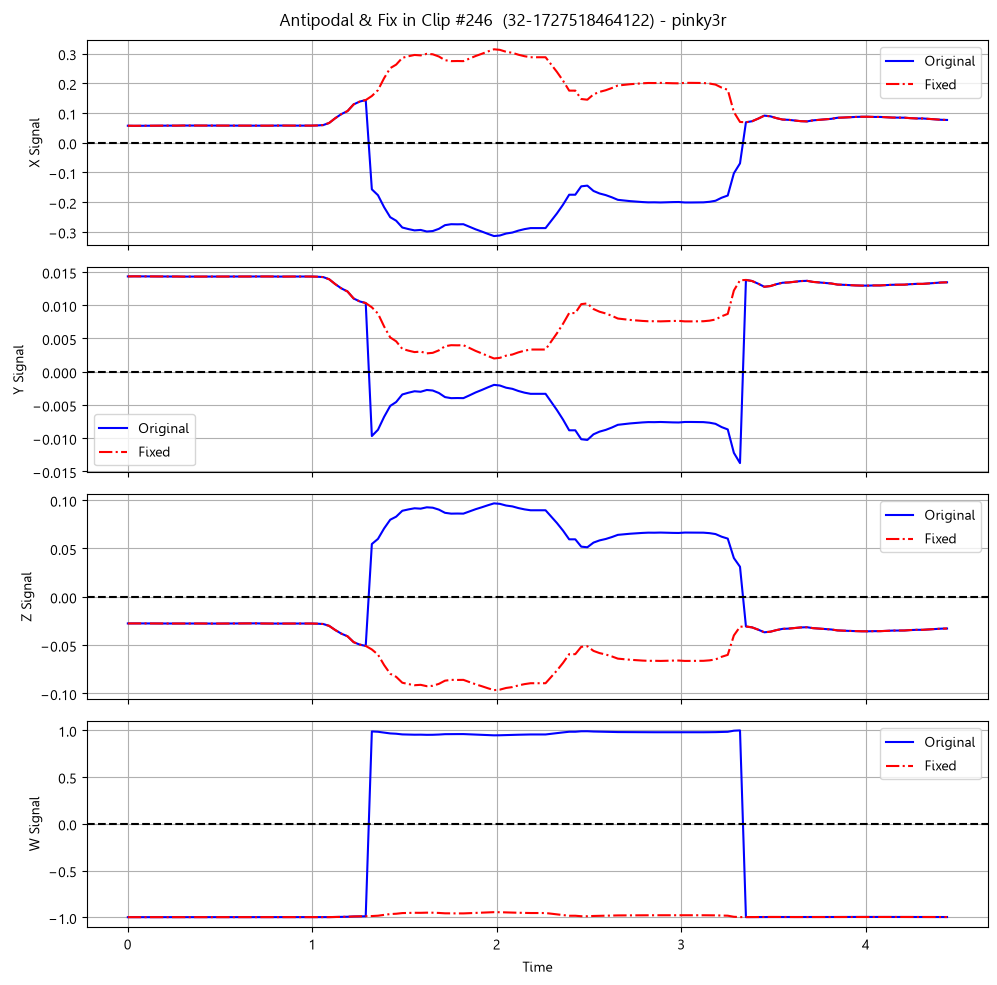

In [9]:
# showcasing antipodal snapping & fix

clip = load_clip("data/json/clip_246.json")
tracks = clip["animationClip"]["tracks"]
track = tracks[get_joint_idx(tracks, "pinky3r")]
prep_track = antipodal.process(track)

plot_quat_signals(dict(
    data = [
        dict(times=track["times"], values=track["values"], label="Original", fmt="b-"),
        dict(times=prep_track["times"], values=prep_track["values"], label="Fixed", fmt="r-."),
        ],
    axhline=0,
    title=f"Antipodal & Fix in Clip #246  ({clip["animationClip"]["name"]}) - pinky3r",
))

In [10]:
# fix clip 246 for viwer showcasing (result show no visual changes)

clip = load_clip("data/json/clip_246.json")
tracks = clip["animationClip"]["tracks"]

for i, track in enumerate(tracks):
    prep_track = antipodal.process(track)
    clip["animationClip"]["tracks"][i] = prep_track

save_clip(clip, "out/temp/clip_246_antipodal_fix.json")

In [11]:
# fix the test clip for further analysis

for i, track in enumerate(quater_tracks):
    prep_track = antipodal.process(track)
    quater_tracks[i] = prep_track
    original_clip["animationClip"]["tracks"][i + len(number_tracks)] = prep_track

---
## Times Consistency

In [12]:
# check for unique groups of times

uniques_times = []

for track in quater_tracks:
    dup = False

    for i, data in enumerate(uniques_times):
        if track["times"] == data["times"]:
            dup = True
            break

    if dup:
        uniques_times[i]["names"].append(track["name"])
    else:
        uniques_times.append(dict(times=track["times"], names=[track["name"]]))


print(f"{len(uniques_times)} uniques times array from {len(quater_tracks)} tracks:\n")
for i, data in enumerate(uniques_times):
    print(f"{i:<5} len = {len(data["times"]):<6} ends_at = {data["times"][-1]:<14.8f} members = {data["names"]}")

23 uniques times array from 47 tracks:

0     len = 216    ends_at = 7.15349007     members = ['rootx.quaternion', 'headx.quaternion', 'arm_stretchr.quaternion', 'forearm_stretchr.quaternion', 'handr.quaternion', 'index1r.quaternion', 'pinky1r.quaternion', 'arm_stretchl.quaternion', 'forearm_stretchl.quaternion', 'handl.quaternion', 'index1l.quaternion', 'index2l.quaternion', 'index3l.quaternion', 'middle1l.quaternion', 'middle2l.quaternion', 'middle3l.quaternion', 'ring1l.quaternion', 'ring2l.quaternion', 'ring3l.quaternion', 'pinky1l.quaternion', 'pinky2l.quaternion', 'pinky3l.quaternion', 'footl.quaternion']
1     len = 194    ends_at = 7.15349007     members = ['spine_01x.quaternion']
2     len = 213    ends_at = 7.15349007     members = ['spine_02x.quaternion']
3     len = 215    ends_at = 7.15349007     members = ['neckx.quaternion']
4     len = 215    ends_at = 7.15349007     members = ['shoulderr.quaternion']
5     len = 213    ends_at = 7.15349007     members = ['thumb1r.quate

In [13]:
# check for repeated timestamps

for i, data in enumerate(uniques_times):
    diffs = np.diff(data["times"])
    print(f"group {i:<5} haveing repeated times? = {np.any(diffs <= 1e-8)}")

group 0     haveing repeated times? = False
group 1     haveing repeated times? = False
group 2     haveing repeated times? = False
group 3     haveing repeated times? = False
group 4     haveing repeated times? = False
group 5     haveing repeated times? = False
group 6     haveing repeated times? = False
group 7     haveing repeated times? = False
group 8     haveing repeated times? = False
group 9     haveing repeated times? = False
group 10    haveing repeated times? = False
group 11    haveing repeated times? = False
group 12    haveing repeated times? = False
group 13    haveing repeated times? = False
group 14    haveing repeated times? = False
group 15    haveing repeated times? = False
group 16    haveing repeated times? = False
group 17    haveing repeated times? = False
group 18    haveing repeated times? = False
group 19    haveing repeated times? = False
group 20    haveing repeated times? = False
group 21    haveing repeated times? = False
group 22    haveing repeated tim

---
## Baking 🧑‍🍳🥐

In [14]:
# test baking

baker_30fps = TrackBaker(lerp_type="slerp", fps=30, duration=original_clip["animationClip"]["duration"])
baked_tracks_30fps = [baker_30fps.process(track) for track in quater_tracks]

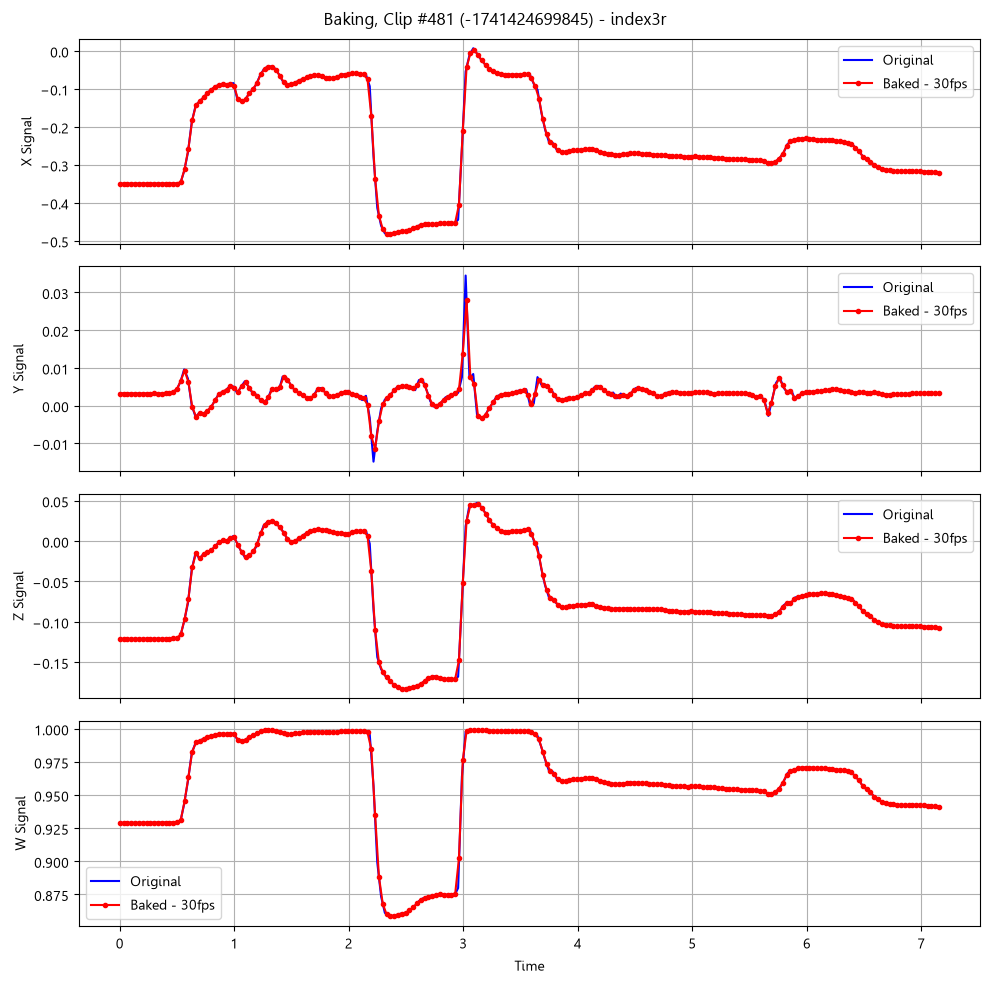

In [15]:
# visualize result from the cell above

show_track_orig = quater_tracks[get_joint_idx(quater_tracks, "index3r")]
show_track_bake = baked_tracks_30fps[get_joint_idx(baked_tracks_30fps, "index3r")]

plot_quat_signals(dict(
    data = [
        dict(times=show_track_orig["times"], values=show_track_orig["values"], label="Original", fmt="b-"),
        dict(times=show_track_bake["times"], values=show_track_bake["values"], label="Baked - 30fps", fmt=".r-"),
        ],
    title=f"Baking, Clip #{CLIP_IDX} ({original_clip["animationClip"]["name"]}) - index3r",
))

In [16]:
# test using baker as sub-sampler

subsampler_10fps = TrackBaker(lerp_type="slerp", fps=10, duration=original_clip["animationClip"]["duration"])
subsampled_tracks_10fps = [subsampler_10fps.process(track) for track in quater_tracks]

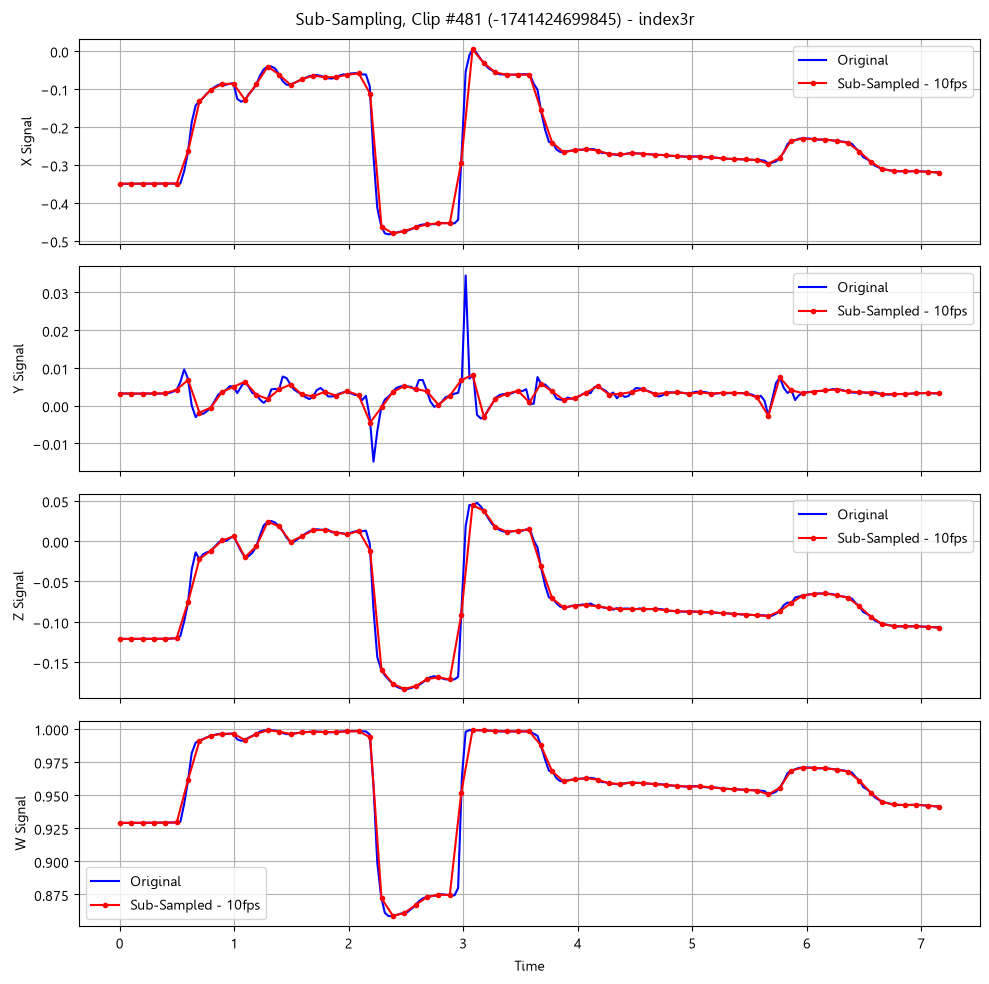

In [17]:
# visualize result from the cell above

show_track_orig = quater_tracks[get_joint_idx(quater_tracks, "index3r")]
show_track_subs = subsampled_tracks_10fps[get_joint_idx(subsampled_tracks_10fps, "index3r")]

plot_quat_signals(dict(
    data = [
        dict(times=show_track_orig["times"], values=show_track_orig["values"], label="Original", fmt="b-"),
        dict(times=show_track_subs["times"], values=show_track_subs["values"], label="Sub-Sampled - 10fps", fmt=".r-"),
        ],
    title=f"Sub-Sampling, Clip #{CLIP_IDX} ({original_clip["animationClip"]["name"]}) - index3r",
))

In [18]:
# test upsampling from sub-sampled data

upsampling_tracks_30fps = [baker_30fps.process(track) for track in subsampled_tracks_10fps]

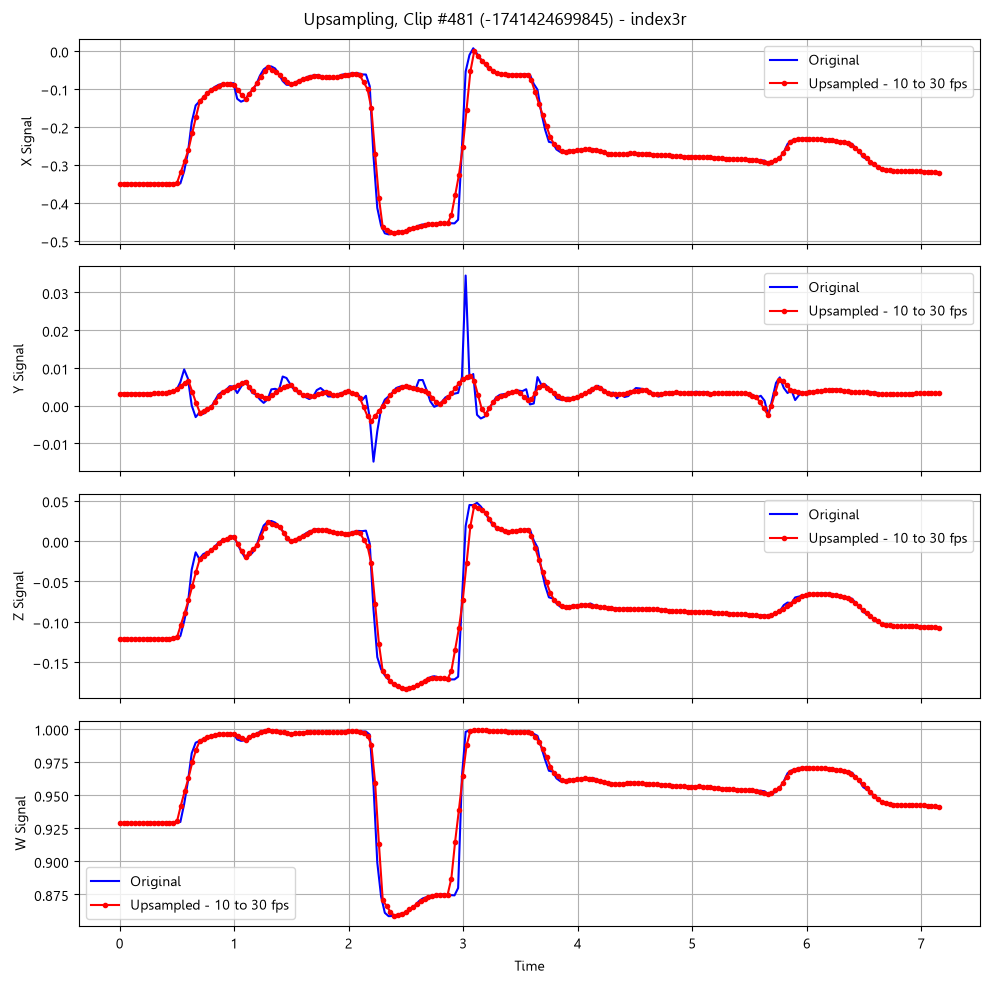

In [19]:
# visualize result from the cell above

show_track_orig = quater_tracks[get_joint_idx(quater_tracks, "index3r")]
show_track_upsm = upsampling_tracks_30fps[get_joint_idx(upsampling_tracks_30fps, "index3r")]

plot_quat_signals(dict(
    data = [
        dict(times=show_track_orig["times"], values=show_track_orig["values"], label="Original", fmt="b-"),
        dict(times=show_track_upsm["times"], values=show_track_upsm["values"], label="Upsampled - 10 to 30 fps", fmt=".r-"),
        ],
    title=f"Upsampling, Clip #{CLIP_IDX} ({original_clip["animationClip"]["name"]}) - index3r",
))

In [20]:
# test saving: see the effect of baking, sub-sampling, and upsampling on real renderer

#! test clips will not have blendshapes
baked_clip = deepcopy(original_clip)
baked_clip["animationClip"]["tracks"] = baked_tracks_30fps
save_clip(baked_clip, f"out/temp/clip_{CLIP_IDX}_baked_30fps.json")

subsampled_clip = deepcopy(original_clip)
subsampled_clip["animationClip"]["tracks"] = subsampled_tracks_10fps
save_clip(subsampled_clip, f"out/temp/clip_{CLIP_IDX}_subsampled_10fps.json")

upsampled_clip = deepcopy(original_clip)
upsampled_clip["animationClip"]["tracks"] = upsampling_tracks_30fps
save_clip(upsampled_clip, f"out/temp/clip_{CLIP_IDX}_upsampled_30fps.json")

---
## Synchronization of Movements

### Correlation in Fingers Movement

In [21]:
LEFT_HAND = [
    "pinky1_basel", "ring1_basel", "middle1_basel", "index1_basel",       
    "thumb1l", "pinky1l", "ring1l", "middle1l", "index1l",            
    "thumb2l", "pinky2l", "ring2l", "middle2l", "index2l",            
    "thumb3l", "pinky3l", "ring3l", "middle3l", "index3l",            
]

RIGHT_HAND = [
    "pinky1_baser", "ring1_baser", "middle1_baser", "index1_baser",       
    "thumb1r", "pinky1r", "ring1r", "middle1r", "index1r",            
    "thumb2r", "pinky2r", "ring2r", "middle2r", "index2r",            
    "thumb3r", "pinky3r", "ring3r", "middle3r", "index3r",            
]

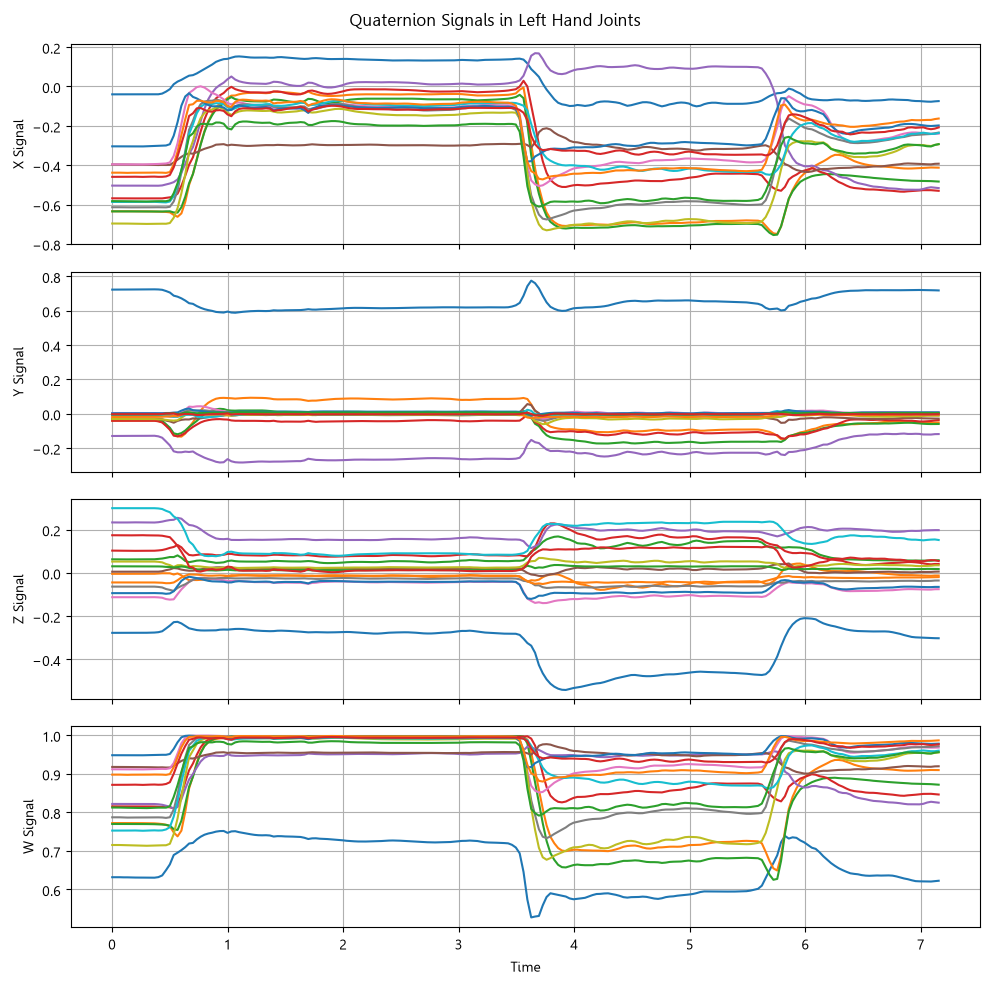

In [22]:
left_hand_data = []
for joint in LEFT_HAND:
    idx = get_joint_idx(baked_tracks_30fps, joint)
    if idx is not None:
        left_hand_data.append(dict(
            times=baked_tracks_30fps[idx]["times"], 
            values=baked_tracks_30fps[idx]["values"], 
            name=joint,
            # label="Original", 
            # fmt="b-"
            )
        )

plot_quat_signals(dict(
    data = left_hand_data,
    title="Quaternion Signals in Left Hand Joints"
))

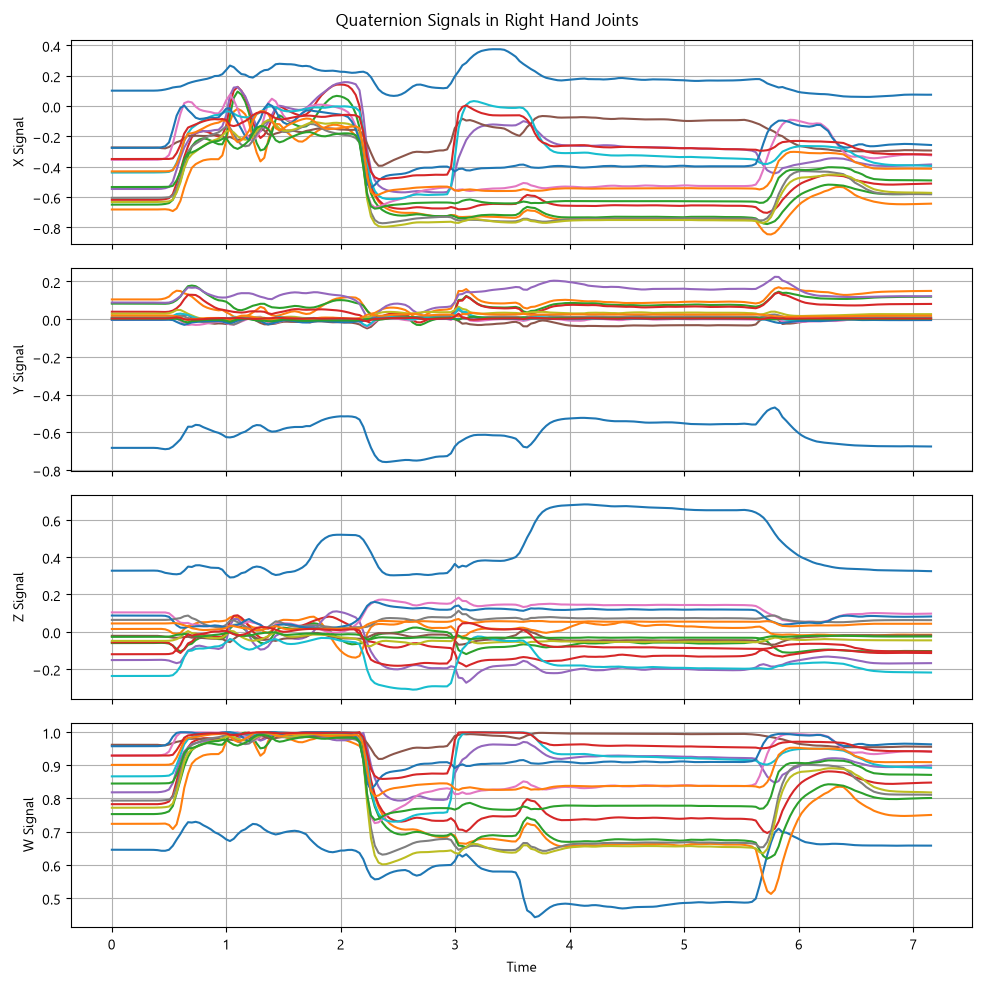

In [23]:
right_hand_data = []
for joint in RIGHT_HAND:
    idx = get_joint_idx(baked_tracks_30fps, joint)
    if idx is not None:
        right_hand_data.append(dict(
            times=baked_tracks_30fps[idx]["times"], 
            values=baked_tracks_30fps[idx]["values"],
            name=joint,
            # label="Original", 
            # fmt="b-"
            )
        )

plot_quat_signals(dict(
    data = right_hand_data,
    title="Quaternion Signals in Right Hand Joints"
))

### PCA, Eigen-Poses for Hands

In [24]:
# packing hands signals into a Dataframe/arr

left_hand_signals = pd.DataFrame()
for data in left_hand_data:
    for i in range(4):
        left_hand_signals[data["name"] + "_" + str(i)] = np.array(data["values"]).reshape(-1, 4)[:, i]

right_hand_signals = pd.DataFrame()
for data in right_hand_data:
    for i in range(4):
        right_hand_signals[data["name"] + "_" + str(i)] = np.array(data["values"]).reshape(-1, 4)[:, i]

right_hand_signals

,thumb1r_0,thumb1r_1,thumb1r_2,thumb1r_3,pinky1r_0,pinky1r_1,pinky1r_2,pinky1r_3,ring1r_0,ring1r_1,...,ring3r_2,ring3r_3,middle3r_0,middle3r_1,middle3r_2,middle3r_3,index3r_0,index3r_1,index3r_2,index3r_3
0,0.100257,-0.682961,0.326979,0.645444,-0.682336,0.104181,0.014279,0.723436,-0.650277,0.082043,...,0.043938,0.900895,-0.534365,0.002518,-0.027904,0.844789,-0.349896,0.003195,-0.121137,0.928918
1,0.100257,-0.682961,0.326979,0.645444,-0.682336,0.104181,0.014279,0.723436,-0.650277,0.082043,...,0.043938,0.900895,-0.534365,0.002518,-0.027904,0.844789,-0.349896,0.003195,-0.121137,0.928918
2,0.100258,-0.682960,0.326981,0.645443,-0.682298,0.104159,0.014298,0.723475,-0.650278,0.082043,...,0.043938,0.900895,-0.534365,0.002518,-0.027904,0.844789,-0.349894,0.003195,-0.121137,0.928919
3,0.100278,-0.682954,0.327128,0.645373,-0.682317,0.104120,0.014312,0.723462,-0.650286,0.081999,...,0.043938,0.900894,-0.534327,0.002512,-0.027888,0.844814,-0.349820,0.003186,-0.121093,0.928952
4,0.100278,-0.682954,0.327128,0.645373,-0.682324,0.104231,0.014391,0.723438,-0.650242,0.082111,...,0.043966,0.900852,-0.534282,0.002454,-0.027887,0.844843,-0.349767,0.003163,-0.121037,0.928980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211,0.074006,-0.674566,0.326611,0.657882,-0.646416,0.148554,-0.016650,0.748199,-0.578841,0.118108,...,0.042313,0.909571,-0.489458,0.001113,-0.025913,0.871641,-0.317689,0.003316,-0.105925,0.942254
212,0.073655,-0.675101,0.325859,0.657746,-0.645637,0.148781,-0.016773,0.748823,-0.578198,0.118170,...,0.042375,0.909402,-0.489873,0.001134,-0.025900,0.871408,-0.318552,0.003343,-0.106272,0.941923
213,0.073618,-0.675403,0.325446,0.657644,-0.645169,0.148875,-0.016706,0.749209,-0.577794,0.118189,...,0.042349,0.909304,-0.490059,0.001112,-0.025959,0.871302,-0.318930,0.003251,-0.106441,0.941777
214,0.073534,-0.675496,0.324890,0.657834,-0.644460,0.149305,-0.016720,0.749733,-0.577395,0.118612,...,0.042478,0.909157,-0.490611,0.001111,-0.025878,0.870994,-0.319939,0.003241,-0.106794,0.941395


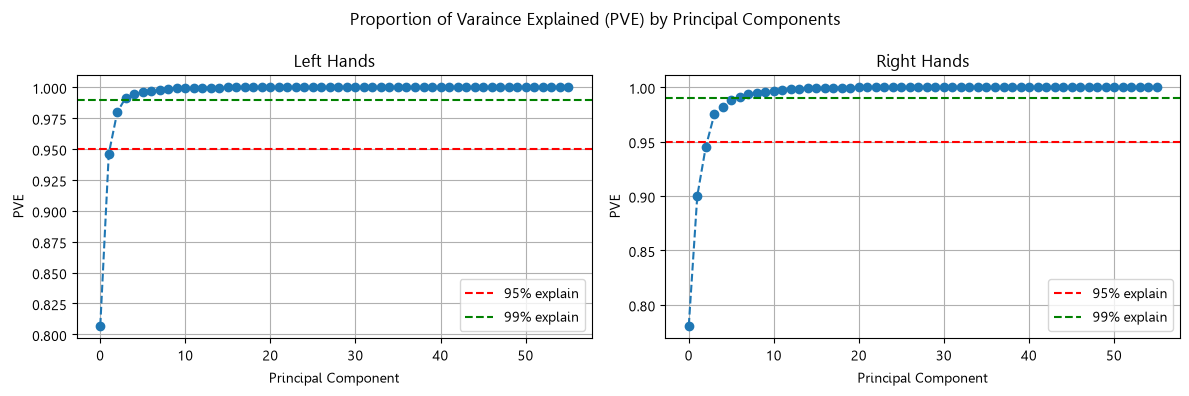

In [25]:
# PCA on hands signals

left_mean  = np.mean(left_hand_signals.values, axis=0)
right_mean = np.mean(right_hand_signals.values, axis=0)
left_hand_centered  = left_hand_signals.values - left_mean
right_hand_centered = right_hand_signals.values - right_mean

left_cov_matrix  = np.cov(left_hand_centered, rowvar=False)
right_cov_matrix = np.cov(right_hand_centered, rowvar=False)

left_eigenvalues , left_eigenvectors  = eigh(left_cov_matrix)
right_eigenvalues, right_eigenvectors = eigh(right_cov_matrix)

idx = np.argsort(left_eigenvalues)[::-1]
left_eigenvectors = left_eigenvectors[:, idx]
left_eigenvalues = left_eigenvalues[idx]

idx = np.argsort(right_eigenvalues)[::-1]
right_eigenvectors = right_eigenvectors[:, idx]
right_eigenvalues = right_eigenvalues[idx]

left_pve  = np.cumsum(left_eigenvalues) / np.sum(left_eigenvalues)
right_pve = np.cumsum(right_eigenvalues) / np.sum(right_eigenvalues)

fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=False)

axs[0].plot(left_pve, "o--")
axs[0].set_title("Left Hands")
axs[1].plot(right_pve, "o--")
axs[1].set_title("Right Hands")

for ax in axs:
    ax.axhline(y=0.95, label="95% explain", linestyle="--", color="red")
    ax.axhline(y=0.99, label="99% explain", linestyle="--", color="green")
    ax.set_xlabel("Principal Component")
    ax.set_ylabel("PVE")
    ax.legend()
    ax.grid()

fig.suptitle("Proportion of Varaince Explained (PVE) by Principal Components")
fig.tight_layout()
plt.show()

In [50]:
# reduction of features

left_top_pcs_idx  = np.searchsorted(left_pve, 0.995)
right_top_pcs_idx = np.searchsorted(right_pve, 0.995)

left_top_pcs_idx  = 1 if left_top_pcs_idx == 0 else left_top_pcs_idx
right_top_pcs_idx = 1 if right_top_pcs_idx == 0 else right_top_pcs_idx

left_top_5_pcs  = left_eigenvectors[:, :left_top_pcs_idx]
right_top_5_pcs = right_eigenvectors[:, :right_top_pcs_idx]
print(f"left={left_top_5_pcs.shape}, right={right_top_5_pcs.shape}")

left_hand_pca  = np.dot(left_hand_centered, left_top_5_pcs)
right_hand_pca = np.dot(right_hand_centered, right_top_5_pcs)
print(f"left={left_hand_pca.shape}, right={right_hand_pca.shape}")

pd.DataFrame(right_hand_pca)

left=(56, 5), right=(56, 9)
left=(216, 5), right=(216, 9)


,0,1,2,3,4,5,6,7,8
0,-0.253684,0.379737,-0.047075,-0.033543,0.029356,0.009020,0.028035,0.020913,0.059014
1,-0.253684,0.379737,-0.047075,-0.033543,0.029356,0.009020,0.028035,0.020913,0.059014
2,-0.253670,0.379762,-0.047045,-0.033542,0.029371,0.009031,0.028041,0.020934,0.059065
3,-0.253721,0.379674,-0.047092,-0.033504,0.029358,0.009126,0.028113,0.021046,0.059123
4,-0.253652,0.379593,-0.047165,-0.033535,0.029374,0.009055,0.028102,0.020942,0.059193
...,...,...,...,...,...,...,...,...,...
211,-0.047915,0.287669,-0.064926,-0.030551,-0.085120,-0.070904,-0.018933,-0.027085,-0.025214
212,-0.048025,0.287911,-0.062330,-0.030928,-0.086419,-0.071936,-0.019789,-0.027559,-0.025904
213,-0.048174,0.287869,-0.060671,-0.030983,-0.086865,-0.072388,-0.020189,-0.027989,-0.026198
214,-0.049226,0.287592,-0.057770,-0.031183,-0.088367,-0.072990,-0.020407,-0.029352,-0.026639


In [27]:
# PCA reconstruction

left_hand_recon  = pd.DataFrame(np.dot(left_hand_pca, left_top_5_pcs.T) + left_mean, columns=left_hand_signals.columns)
right_hand_recon = pd.DataFrame(np.dot(right_hand_pca, right_top_5_pcs.T) + right_mean, columns=right_hand_signals.columns)

left_hand_recon

,thumb1l_0,thumb1l_1,thumb1l_2,thumb1l_3,pinky1l_0,pinky1l_1,pinky1l_2,pinky1l_3,ring1l_0,ring1l_1,...,ring3l_2,ring3l_3,middle3l_0,middle3l_1,middle3l_2,middle3l_3,index3l_0,index3l_1,index3l_2,index3l_3
0,-0.033353,0.722776,-0.273393,0.633762,-0.628582,-0.049420,-0.006575,0.770492,-0.630728,-0.041076,...,-0.044687,0.900941,-0.581665,-0.003021,0.029457,0.815113,-0.459370,-0.002017,0.172816,0.874438
1,-0.033469,0.722790,-0.273465,0.633713,-0.628612,-0.049430,-0.006585,0.770481,-0.630805,-0.041072,...,-0.044682,0.900964,-0.581608,-0.003019,0.029454,0.815148,-0.459397,-0.002016,0.172828,0.874436
2,-0.033552,0.722910,-0.273575,0.633532,-0.628465,-0.049339,-0.006605,0.770578,-0.630747,-0.040999,...,-0.044701,0.900913,-0.581774,-0.003024,0.029458,0.815076,-0.459489,-0.002015,0.172869,0.874415
3,-0.033545,0.723119,-0.273446,0.633390,-0.628434,-0.049361,-0.006565,0.770739,-0.630761,-0.041003,...,-0.044731,0.900828,-0.582086,-0.003035,0.029471,0.814945,-0.459481,-0.002019,0.172863,0.874429
4,-0.033509,0.723229,-0.273403,0.633303,-0.628427,-0.049322,-0.006556,0.770782,-0.630757,-0.040961,...,-0.044757,0.900748,-0.582352,-0.003043,0.029482,0.814821,-0.459596,-0.002019,0.172915,0.874386
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211,-0.086595,0.710443,-0.288452,0.634749,-0.401219,-0.058877,-0.001172,0.914978,-0.476115,-0.064547,...,-0.020663,0.986762,-0.299422,0.004214,0.017416,0.956653,-0.210328,-0.003553,0.055111,0.977844
212,-0.086577,0.709675,-0.290895,0.634130,-0.401028,-0.057704,-0.001834,0.913793,-0.475839,-0.064024,...,-0.020772,0.986310,-0.300542,0.004194,0.017442,0.955947,-0.212123,-0.003510,0.055954,0.977145
213,-0.086407,0.709011,-0.292357,0.633975,-0.400747,-0.056794,-0.002263,0.912926,-0.475402,-0.063490,...,-0.020815,0.986088,-0.300964,0.004193,0.017445,0.955602,-0.213466,-0.003477,0.056588,0.976583
214,-0.087561,0.707568,-0.293999,0.634571,-0.399551,-0.056455,-0.002639,0.912528,-0.474668,-0.063254,...,-0.020438,0.987304,-0.296792,0.004328,0.017255,0.957530,-0.212693,-0.003437,0.056234,0.976894


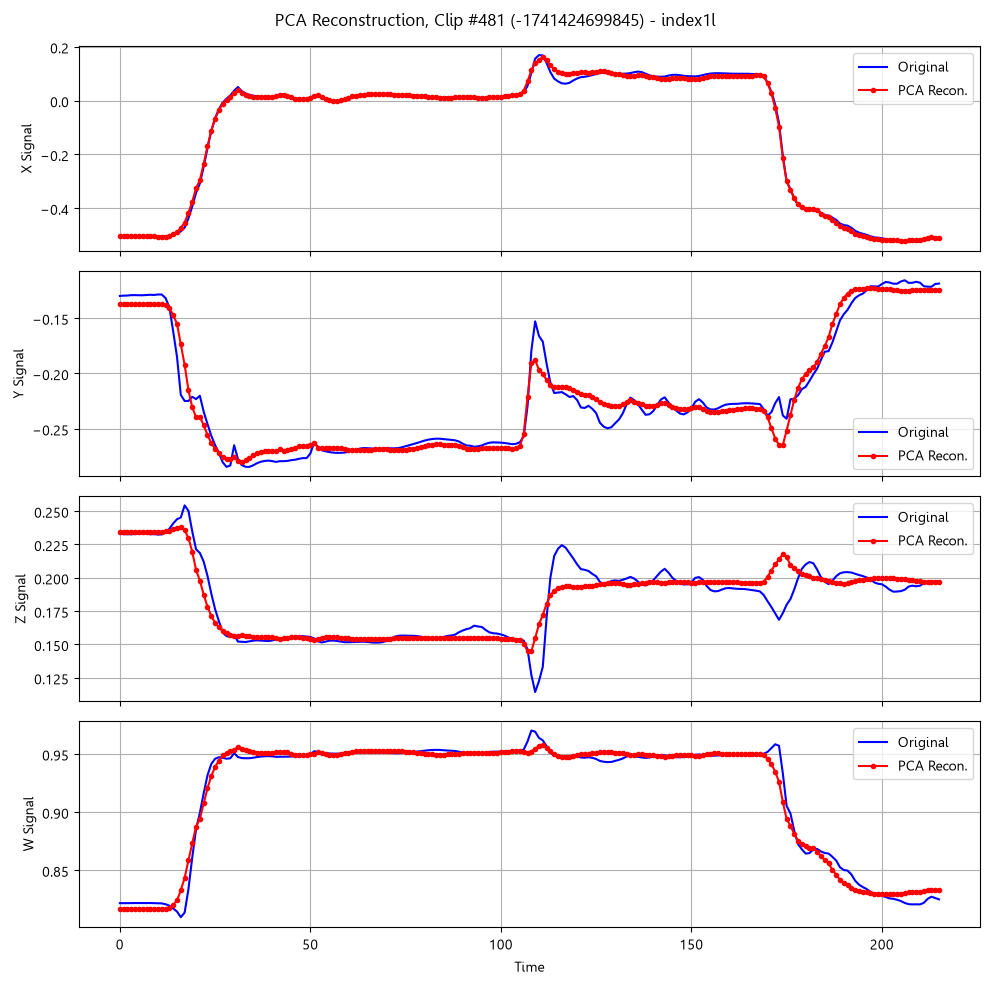

In [28]:
# visualize PCA recon. for left hand

show_joint = "index1l"
cols = [f"{show_joint}_{i}" for i in range(4)]
plot_quat_signals(dict(
    data = [
        dict(times=np.arange(left_hand_signals.shape[0]), values=left_hand_signals[cols], label="Original", fmt="b-"),
        dict(times=np.arange(left_hand_recon.shape[0]), values=left_hand_recon[cols], label="PCA Recon.", fmt=".r-"),
        ],
    title=f"PCA Reconstruction, Clip #{CLIP_IDX} ({original_clip["animationClip"]["name"]}) - {show_joint}",
))

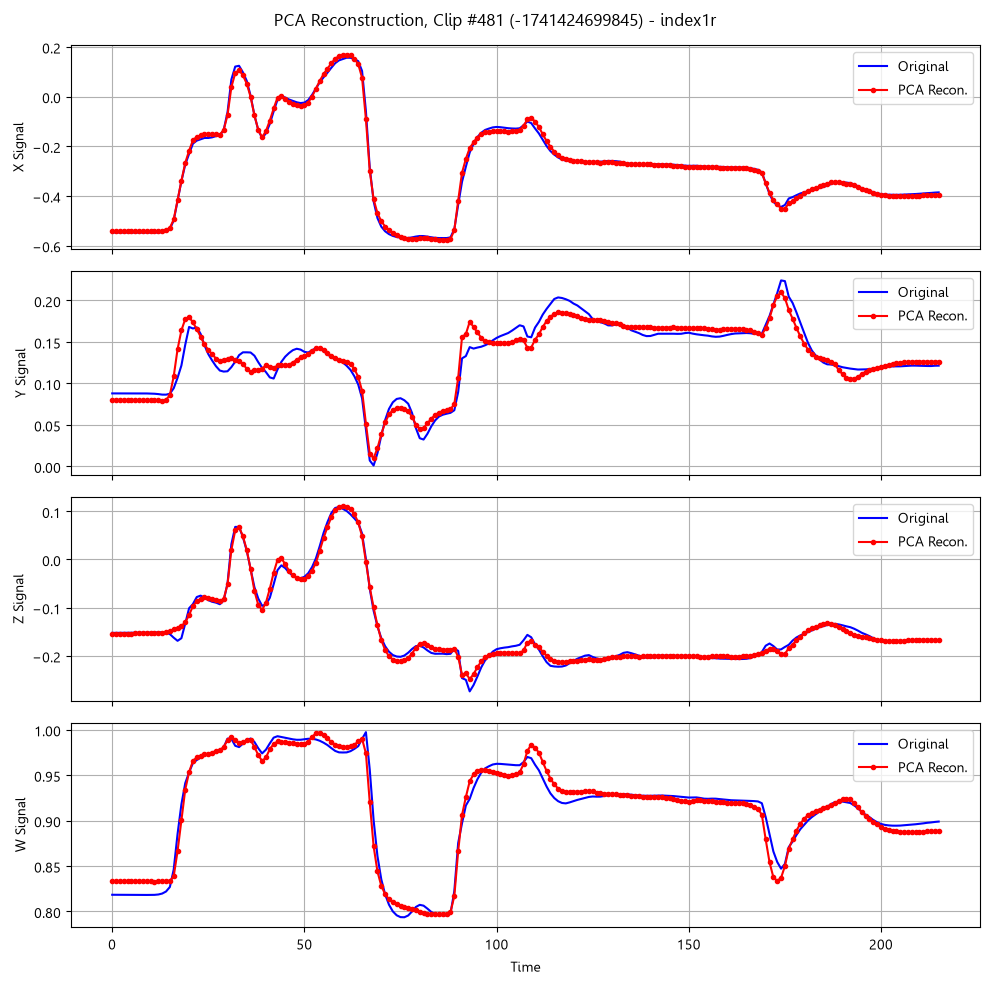

In [29]:
# visualize PCA recon. for right hand

show_joint = "index1r"
cols = [f"{show_joint}_{i}" for i in range(4)]
plot_quat_signals(dict(
    data = [
        dict(times=np.arange(right_hand_signals.shape[0]), values=right_hand_signals[cols], label="Original", fmt="b-"),
        dict(times=np.arange(right_hand_recon.shape[0]), values=right_hand_recon[cols], label="PCA Recon.", fmt=".r-"),
        ],
    title=f"PCA Reconstruction, Clip #{CLIP_IDX} ({original_clip["animationClip"]["name"]}) - {show_joint}",
))

In [30]:
# test saving: see the effect of PCA on real renderer

#! test clips will not have blendshapes
pca_recon_clip = deepcopy(original_clip)

for joint in LEFT_HAND:
    idx = get_joint_idx(pca_recon_clip["animationClip"]["tracks"], joint)

    if idx is not None:
        cols = [f"{joint}_{i}" for i in range(4)]
        values = left_hand_recon[cols].values.reshape(-1)
        pca_recon_clip["animationClip"]["tracks"][idx]["times"] = baked_tracks_30fps[0]["times"]
        pca_recon_clip["animationClip"]["tracks"][idx]["values"] = values

for joint in RIGHT_HAND:
    idx = get_joint_idx(pca_recon_clip["animationClip"]["tracks"], joint)

    if idx is not None:
        cols = [f"{joint}_{i}" for i in range(4)]
        values = right_hand_recon[cols].values.reshape(-1)
        pca_recon_clip["animationClip"]["tracks"][idx]["times"] = baked_tracks_30fps[0]["times"]
        pca_recon_clip["animationClip"]["tracks"][idx]["values"] = values

save_clip(pca_recon_clip, f"out/temp/clip_{CLIP_IDX}_pca_recon.json")

---
## B-Spline Approximation & Residuals for Body Joints

### B-Spline Fitting

In [31]:
# define the LSPIA solver

solver = LSPIASolver(
    degree=3,
    initial_num_cps=15,
    initializer=SimpleInitializer(),
    knot_topo=BoehmKnotOptimizer(tolerance=1e-3, max_insertion_per_step=5),
    tolerance=1e-4,
    max_iters=500,
    convergence_iters=50,
    macro_iters=15,
)

In [32]:
# fitting on test track

test_joint = "arm_stretchr"
test_track = baked_tracks_30fps[get_joint_idx(baked_tracks_30fps, test_joint)]

spline, data_times = solver.fit(np.array(test_track["values"]).reshape(-1, 4), test_track["times"])

print("input shape :", np.array(test_track["values"]).reshape(-1, 4).shape)
print("output shape:", spline.control_points.shape)

input shape : (216, 4)
output shape: (32, 4)


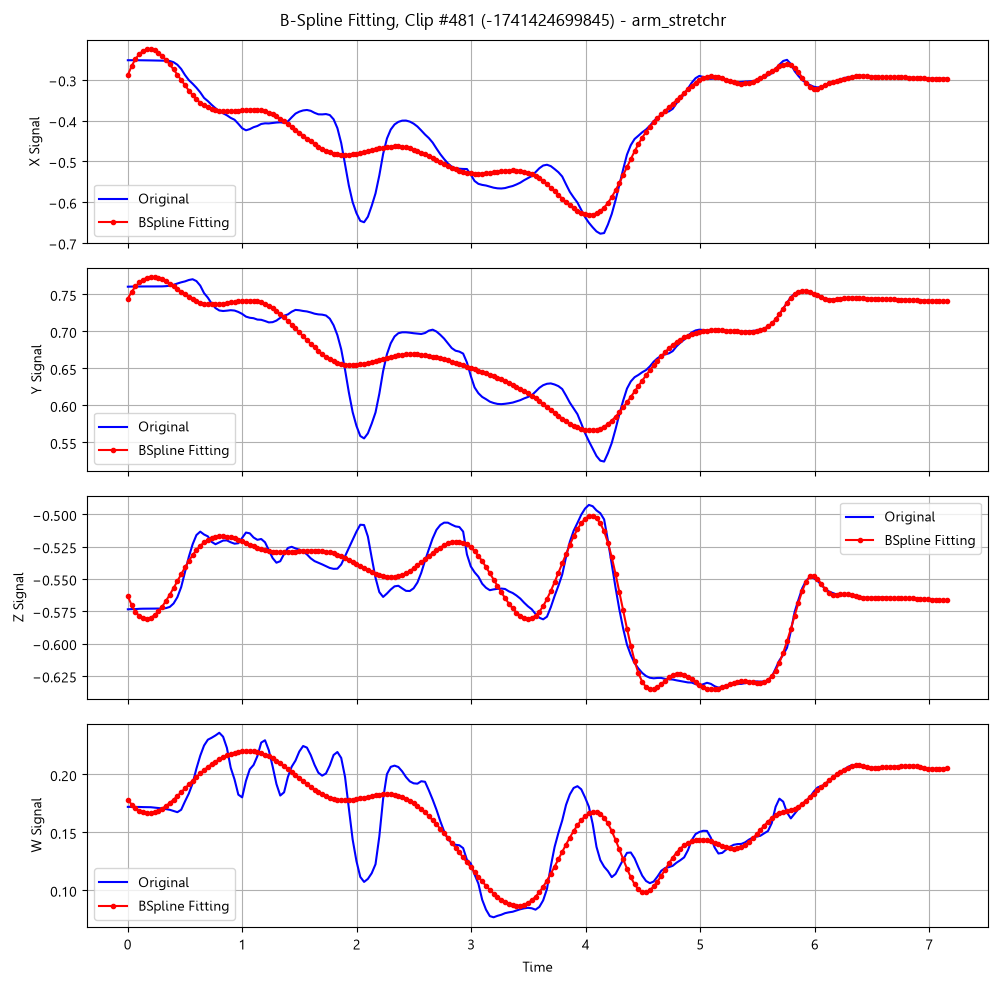

In [33]:
# viusualizaing the result from the cell above

plot_quat_signals(dict(
    data = [
        dict(times=test_track["times"], values=np.array(test_track["values"]).reshape(-1, 4), label="Original", fmt="b-"),
        dict(times=test_track["times"], values=spline(data_times), label="BSpline Fitting", fmt=".r-"),
        ],
    title=f"B-Spline Fitting, Clip #{CLIP_IDX} ({original_clip["animationClip"]["name"]}) - {test_joint}",
))

### Fitting Residuals

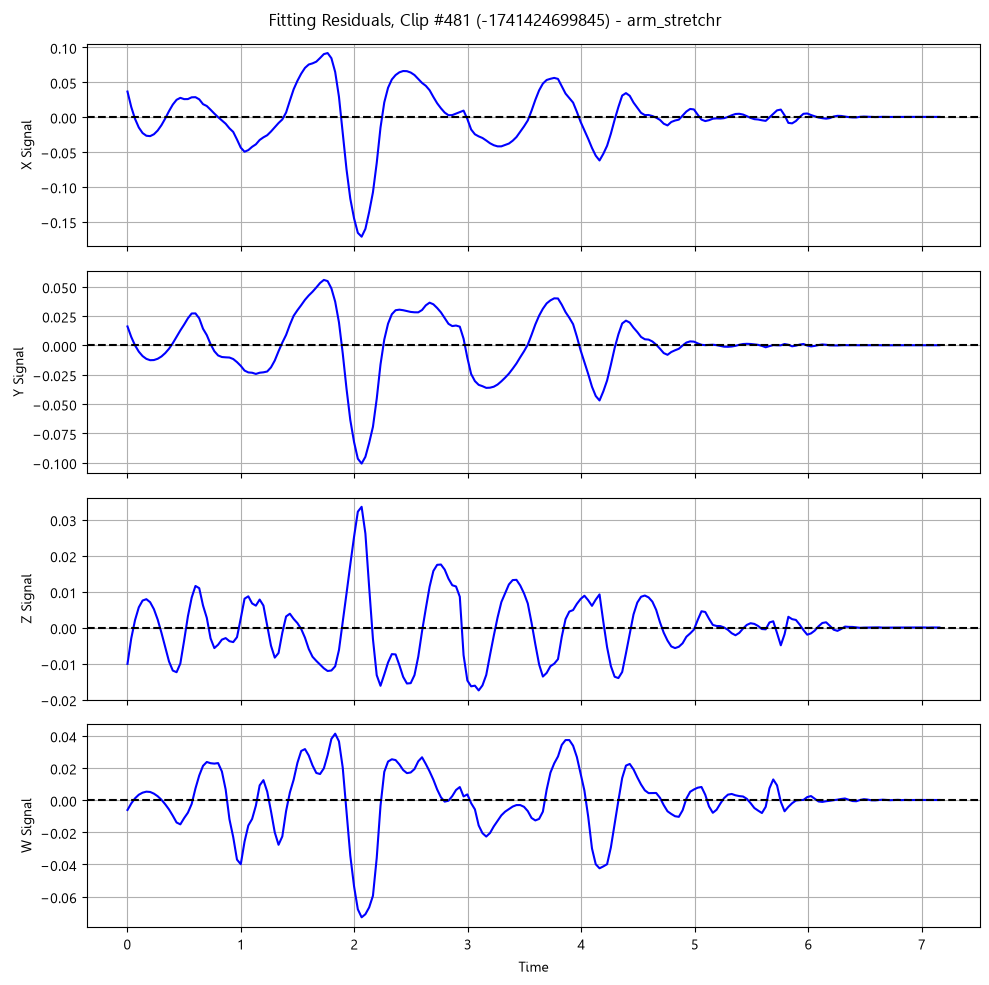

In [34]:
# calculating and plot quaternion residuals

residuals = np.array(test_track["values"]).reshape(-1, 4) - spline(data_times)

plot_quat_signals(dict(
    data = [
        dict(times=test_track["times"], values=residuals, fmt="b-"),
        ],
    axhline=0,
    title=f"Fitting Residuals, Clip #{CLIP_IDX} ({original_clip["animationClip"]["name"]}) - {test_joint}",
))

### Sub-Sampling the Residuals

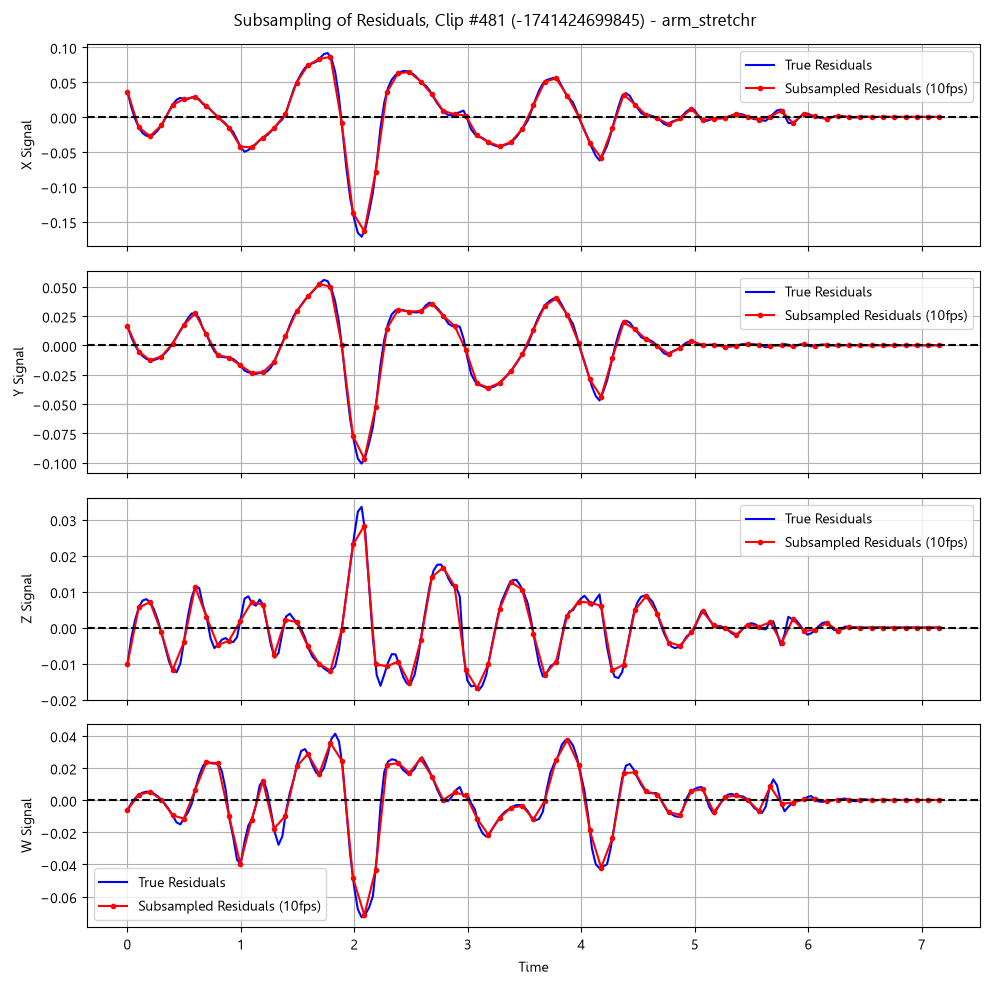

In [35]:
# subsampling the residuals (1st compression strategy)

# pack residuals into track (for compatability with the baker/subsampler)
residuals_track = dict(
    name=f"{test_joint}_residuals",
    type="quaternion",
    values=residuals.reshape(-1),
    times=test_track["times"],
)

res_subsampler_10fps = TrackBaker(lerp_type="lerp", fps=10, duration=original_clip["animationClip"]["duration"])
subsampled_residuals_10fps = res_subsampler_10fps.process(residuals_track)

plot_quat_signals(dict(
    data = [
        dict(times=test_track["times"], values=residuals, label="True Residuals", fmt="b-"),
        dict(times=subsampled_residuals_10fps["times"], values=subsampled_residuals_10fps["values"], label="Subsampled Residuals (10fps)", fmt="r.-"),
        ],
    axhline=0,
    title=f"Subsampling of Residuals, Clip #{CLIP_IDX} ({original_clip["animationClip"]["name"]}) - {test_joint}",
))

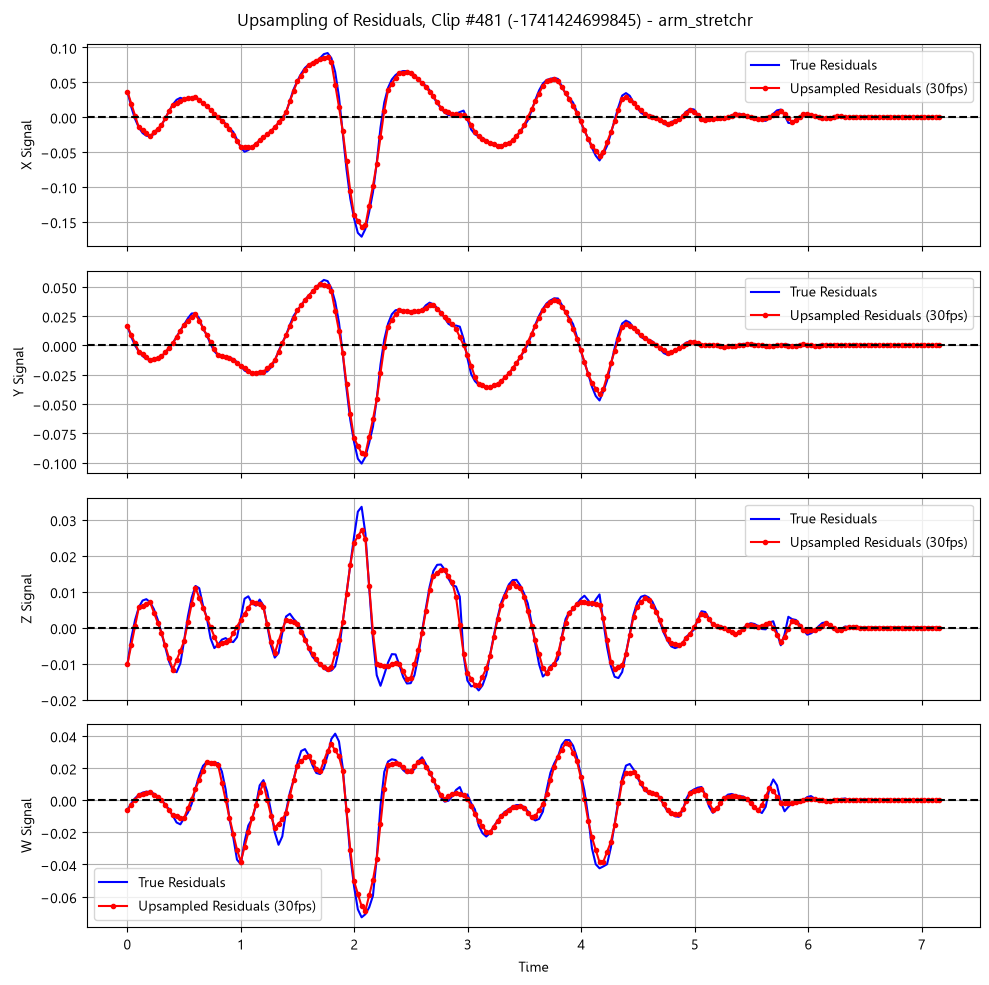

In [36]:
# test residual upsampling for reconstruction

res_upsampler_30fps = TrackBaker(lerp_type="lerp", fps=30, duration=original_clip["animationClip"]["duration"])
upsampled_residuals_30fps = res_upsampler_30fps.process(subsampled_residuals_10fps)

plot_quat_signals(dict(
    data = [
        dict(times=test_track["times"], values=residuals, label="True Residuals", fmt="b-"),
        dict(times=upsampled_residuals_30fps["times"], values=upsampled_residuals_30fps["values"], label="Upsampled Residuals (30fps)", fmt="r.-"),
        ],
    axhline=0,
    title=f"Upsampling of Residuals, Clip #{CLIP_IDX} ({original_clip["animationClip"]["name"]}) - {test_joint}",
))

### DCT on Residuals

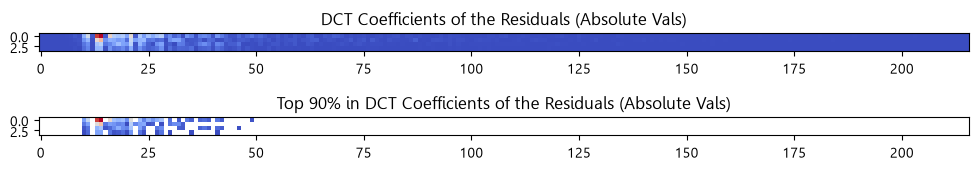

In [37]:
# perform DCT and reduce the coefs

dct_res_coefs = dctn(residuals, type=2, norm="ortho")

thres = 90
flat_coeffs = np.abs(dct_res_coefs.flatten())
threshold = np.percentile(flat_coeffs, thres)

compressed_dct_coeffs = np.where(np.abs(dct_res_coefs) >= threshold, dct_res_coefs, 0)
compressed_dct_coeffs_plot = np.where(np.abs(dct_res_coefs) >= threshold, dct_res_coefs, np.nan)

fig, axs = plt.subplots(2, 1, figsize=(12, 2))
axs[0].imshow(np.abs(dct_res_coefs).T, cmap="coolwarm")
axs[0].set_title("DCT Coefficients of the Residuals (Absolute Vals)")
axs[1].imshow(np.abs(compressed_dct_coeffs_plot).T, cmap="coolwarm")
axs[1].set_title(f"Top {thres}% in DCT Coefficients of the Residuals (Absolute Vals)")
plt.show()

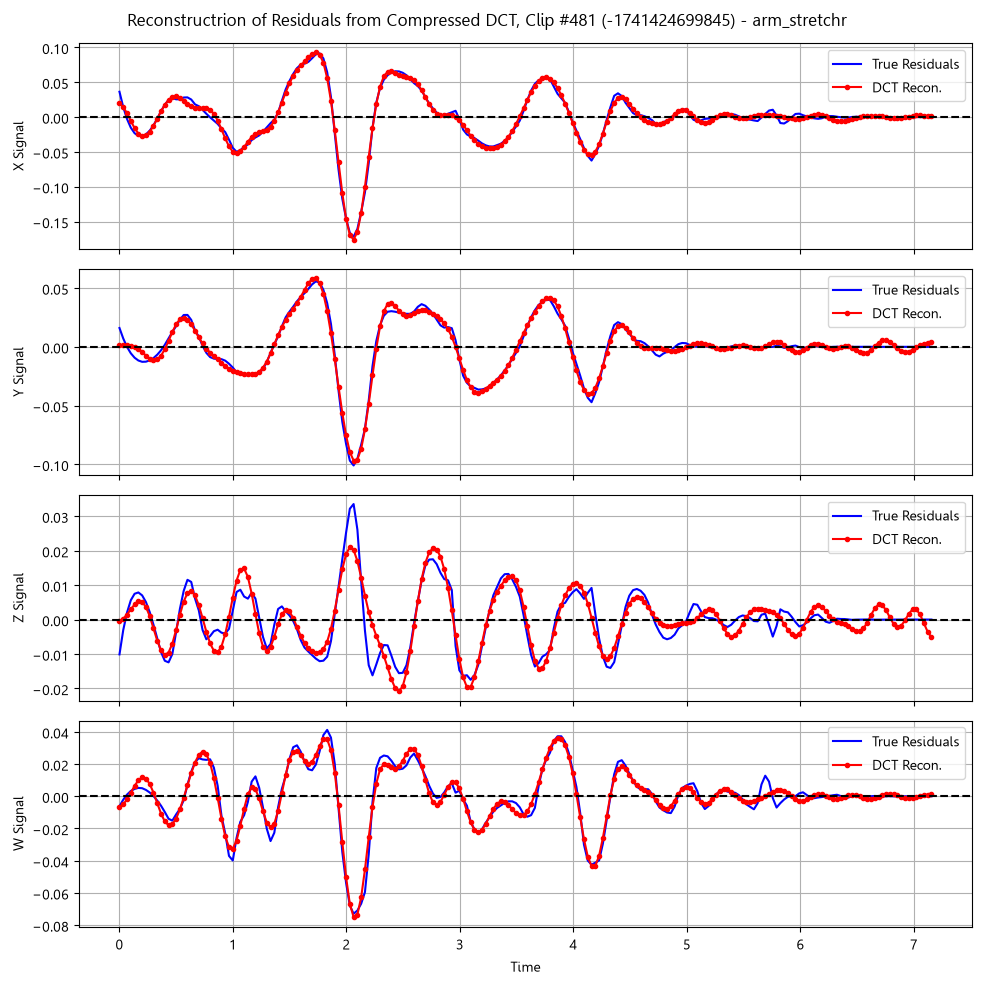

In [38]:
# DCT reconstruction

dct_recon_res = idctn(compressed_dct_coeffs, type=2, norm="ortho")

plot_quat_signals(dict(
    data = [
        dict(times=test_track["times"], values=residuals, label="True Residuals", fmt="b-"),
        dict(times=test_track["times"], values=dct_recon_res, label="DCT Recon.", fmt="r.-"),
        ],
    axhline=0,
    title=f"Reconstructrion of Residuals from Compressed DCT, Clip #{CLIP_IDX} ({original_clip["animationClip"]["name"]}) - {test_joint}",
))

### Reconstruction of Quaternion using Spline + Residuals

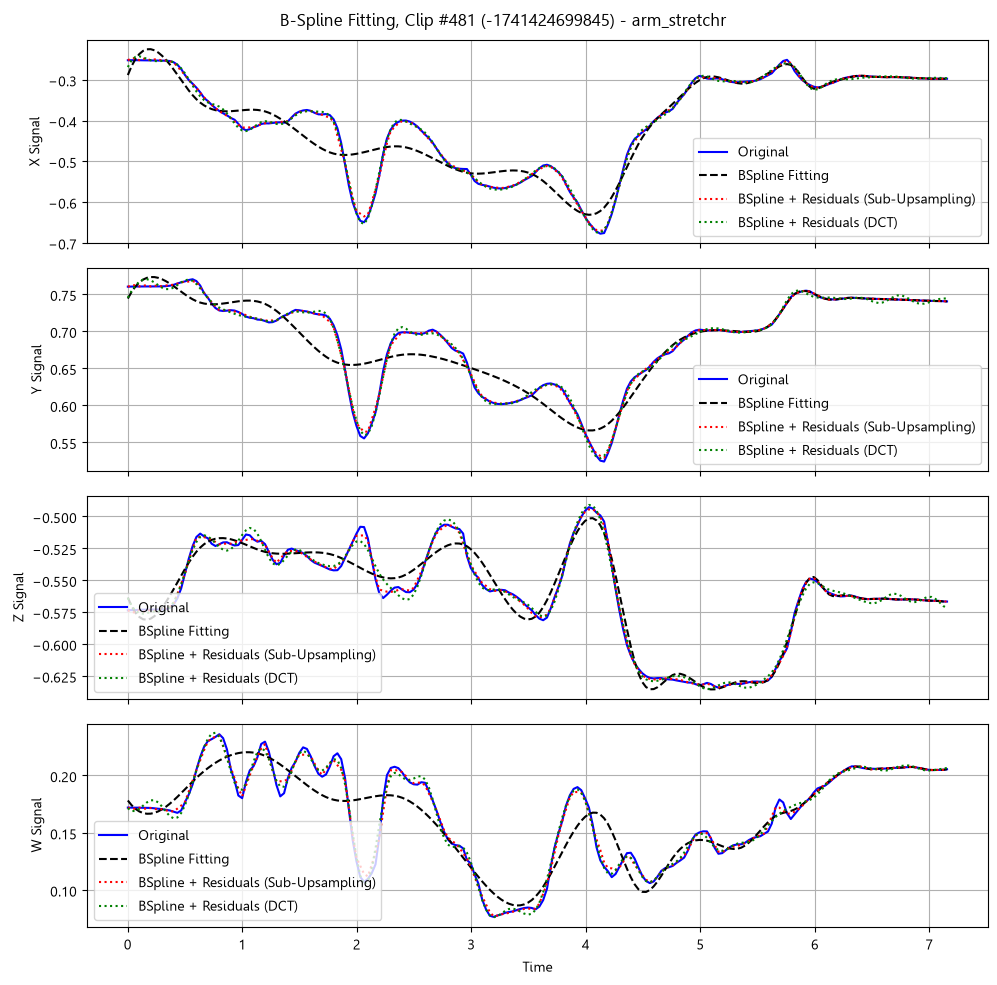

In [39]:
# viusualizaing the result from the cell above

recon_sub_and_upsampling = spline(data_times) + upsampled_residuals_30fps["values"].reshape(-1, 4)
recon_dct = spline(data_times) + dct_recon_res

plot_quat_signals(dict(
    data = [
        dict(times=test_track["times"], values=np.array(test_track["values"]).reshape(-1, 4), label="Original", fmt="b-"),
        dict(times=test_track["times"], values=spline(data_times), label="BSpline Fitting", fmt="k--"),
        dict(times=test_track["times"], values=recon_sub_and_upsampling, label="BSpline + Residuals (Sub-Upsampling)", fmt="r:"),
        dict(times=test_track["times"], values=recon_dct, label="BSpline + Residuals (DCT)", fmt="g:"),
        ],
    title=f"B-Spline Fitting, Clip #{CLIP_IDX} ({original_clip["animationClip"]["name"]}) - {test_joint}",
))

---
## B-Spline Approximation & Residuals for Hands Eigen-Poses

### B-Spline Fitting

In [40]:
# define the LSPIA solver

solver = LSPIASolver(
    degree=3,
    initial_num_cps=5,
    initializer=SimpleInitializer(),
    knot_topo=BoehmKnotOptimizer(tolerance=1e-3, max_insertion_per_step=5),
    tolerance=1e-6,
    max_iters=500,
    convergence_iters=50,
    macro_iters=15,
)

In [41]:
# fitting on left hand pc's

splines = []
data_times = []

for pc in left_hand_pca.T:
    spl, ts = solver.fit(np.atleast_2d(pc).T, test_track["times"])
    splines.append(spl)
    data_times.append(ts)

print("input shape:", left_hand_pca[:, :4].shape)
print("output shapes:", [spl.control_points.shape for spl in splines])

input shape: (216, 4)
output shapes: [(40, 1), (36, 1), (38, 1), (37, 1), (36, 1)]


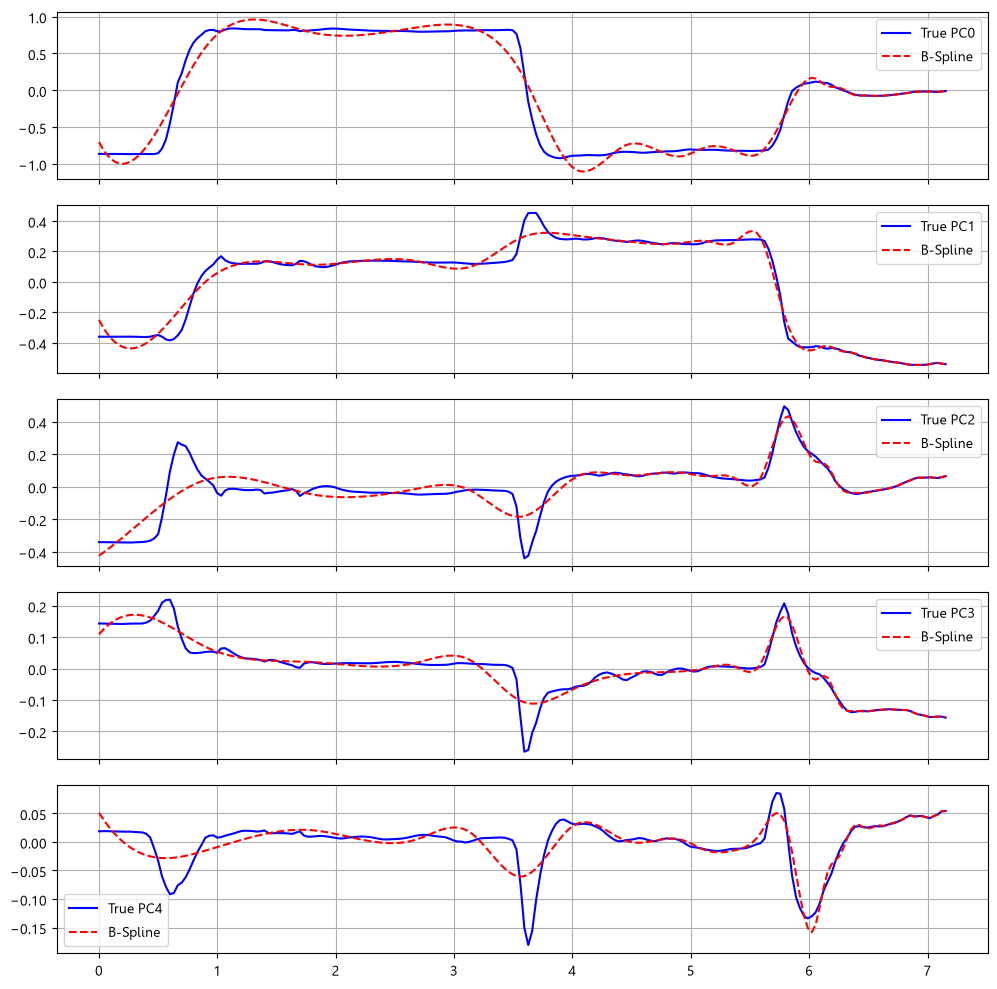

In [42]:
# viusualizaing the result from the cell above

fig, axs = plt.subplots(5, 1, figsize=(10,10), sharex=True)

for i, (pc, spl, ts) in enumerate(zip(left_hand_pca.T, splines, data_times)):
    axs[i].plot(test_track["times"], np.atleast_2d(pc).T, "b-", label=f"True PC{i}")
    axs[i].plot(test_track["times"], spl(ts), "r--", label="B-Spline")
    axs[i].legend()
    axs[i].grid()

fig.tight_layout()
plt.show()